In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pickle

### Caricamento dataframe elaborato

In [2]:
df = pd.read_csv("../data/processed/european_yearly_energy_mix_and_prices.csv")

In [3]:
df.columns

Index(['Area', 'ISO3 Code', 'Year', 'Demand', 'Net Imports',
       'Total Generation', 'Clean', 'Nuclear', 'Wind and Solar', 'Wind',
       'Solar', 'Hydro, Bioenergy and Other Renewables', 'Hydro', 'Bioenergy',
       'Other Renewables', 'Fossil', 'Coal', 'Gas and Other Fossil', 'Gas',
       'Other Fossil', 'AvgPrice_EUR_MWh', 'MaxPrice_EUR_MWh',
       'StdPrice_EUR_MWh'],
      dtype='object')

In [4]:
df.head()

,Area,ISO3 Code,Year,Demand,Net Imports,Total Generation,Clean,Nuclear,Wind and Solar,Wind,...,Bioenergy,Other Renewables,Fossil,Coal,Gas and Other Fossil,Gas,Other Fossil,AvgPrice_EUR_MWh,MaxPrice_EUR_MWh,StdPrice_EUR_MWh
0,Austria,AUT,2015,71.84,10.06,61.78,47.59,0.0,5.78,4.84,...,4.65,0.0,14.19,2.95,11.24,7.66,3.58,31.764167,39.37,3.817206
1,Austria,AUT,2016,72.03,7.16,64.87,51.08,0.0,6.33,5.23,...,4.78,0.0,13.79,2.04,11.75,8.49,3.26,28.956667,38.21,5.792114
2,Austria,AUT,2017,73.64,6.55,67.09,51.05,0.0,7.84,6.57,...,4.92,0.0,16.04,1.76,14.28,10.91,3.37,34.419167,52.41,6.841540
3,Austria,AUT,2018,73.62,8.95,64.67,50.06,0.0,7.49,6.03,...,4.93,0.0,14.61,1.81,12.80,9.92,2.88,40.891667,48.63,6.231735
4,Austria,AUT,2019,73.82,3.13,70.69,54.64,0.0,9.15,7.45,...,4.66,0.0,16.05,1.50,14.55,11.32,3.23,40.137500,56.68,6.267981


# Q1: Relazione tra energia pulita e prezzo dell'elettricità
Vogliamo comprendere se a parità di anno, i paesi con maggior quota di produzione di energia pulita hanno prezzi medi dell'elettricità più alta.

In [5]:
year = 2022
df_y = df[df["Year"] == year].copy()

Di seguito vengono definite le quote di produzione per l'energia pulita, così che possano essere confrontabili tra i vari paesi.

In [6]:
df_y["clean_share"] = df_y["Clean"] / df_y["Total Generation"]

In [7]:
df_y[["clean_share", "AvgPrice_EUR_MWh"]].describe()

,clean_share,AvgPrice_EUR_MWh
count,29.000000,29.000000
mean,0.641181,231.514914
std,0.218377,47.829794
min,0.211030,119.453333
25%,0.499104,214.795833
50%,0.634752,241.204167
75%,0.808644,270.901667
max,0.986453,303.088333


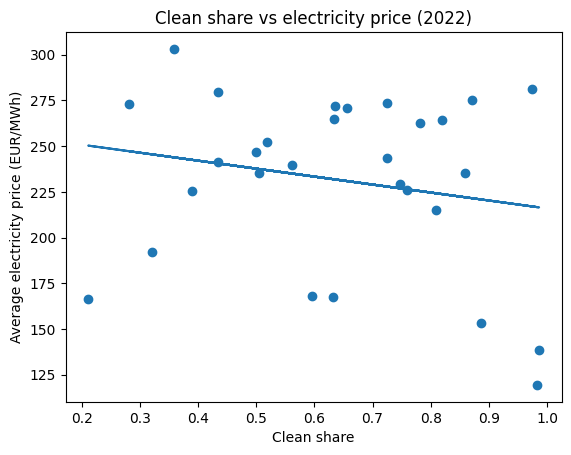

In [8]:
x = df_y["clean_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Clean share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Clean share vs electricity price ({year})")
plt.show()

In [9]:
df_y["clean_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(-0.19880154520090557)

Come si può osservare, per l'anno 2022, esiste una correlazione debolmente negativa tra le quote di energia pulita e il prezzo dell'energia elettrica. <br>
Questo può essere dovuto dal fatto che nel dataset originale la variabile `Clean` include anche la produzione nucleare. <br>
Poiché il nucleare presenta costi derivati nettamente superiori alle altre fonti rinnovabili (costo di costruzione, costo di manutenzione, produzione continua e bassa variabilità), è appropriato dividere i casi di studio su: <br>
- relazione tra energia rinnovabile e prezzo dell'elettricità
- realzione tra energia nucleare e prezzo dell'elettricità

Si ha la necessità di definire la variaible `Renewables` che aggreghi `Wind and Solar` e `Hydro, Bioenergy and Other Renewables`.

In [10]:
df_y["Renewables"] = (
    df_y["Wind and Solar"] +
    df_y["Hydro, Bioenergy and Other Renewables"]
)

Vengono definite le quote di produzione dell'energia elettrica distinte per fonte nucleare e fonti rinnovabili

In [11]:
df_y["nuclear_share"] = df_y["Nuclear"] / df_y["Total Generation"]
df_y["renewables_share"] = df_y["Renewables"] / df_y["Total Generation"]

In [12]:
df_y[["nuclear_share", "renewables_share", "AvgPrice_EUR_MWh"]].describe()

,nuclear_share,renewables_share,AvgPrice_EUR_MWh
count,29.000000,29.000000,29.000000
mean,0.170523,0.470657,231.514914
std,0.208780,0.231462,47.829794
min,0.000000,0.128628,119.453333
25%,0.000000,0.281860,214.795833
50%,0.034727,0.428034,241.204167
75%,0.351115,0.634752,270.901667
max,0.629429,0.986453,303.088333


Viene ricaricato il dataset che include le nuove variabili:
- `Renewables` -> aggregazione di `Wind and Solar` e `Hydro, Bioenergy and Other Renewables`
- `renewables_share` -> quota della produzione rinnovabile
- `nuclear_share` -> quota della produzione nucleare

Scatterplot per evidenziare una possibile correlazione tra le percentuali di produzione di energia rinnovabile e il prezzo medio dell'elettricità

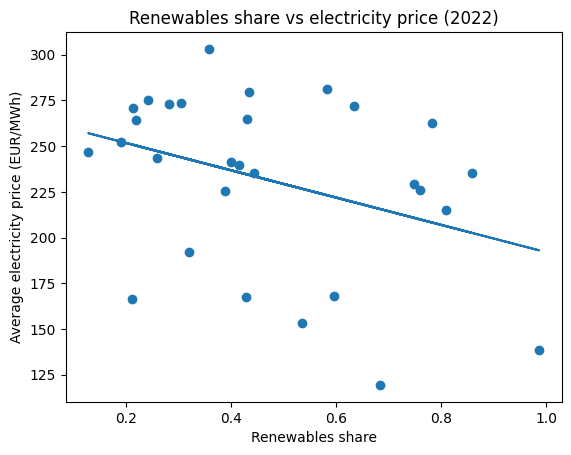

In [13]:
x = df_y["renewables_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Renewables share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Renewables share vs electricity price ({year})")
plt.show()

In [14]:
df_y["renewables_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(-0.36129115030012054)

Per l'anno 2022 si evidenzia una correlazione moderatamente negativa tra la quota di produzione da fonti rinnovabili e prezzi medi dell'elettricità. <br>
In quel periodo i paesi con più rinnovabili tendono ad avere prezzi più bassi.

Scatterplot per evidenziare una possibile correlazione tra le percentuali di produzione di energia nucleare e il prezzo medio dell'elettricità

<Figure size 640x480 with 0 Axes>

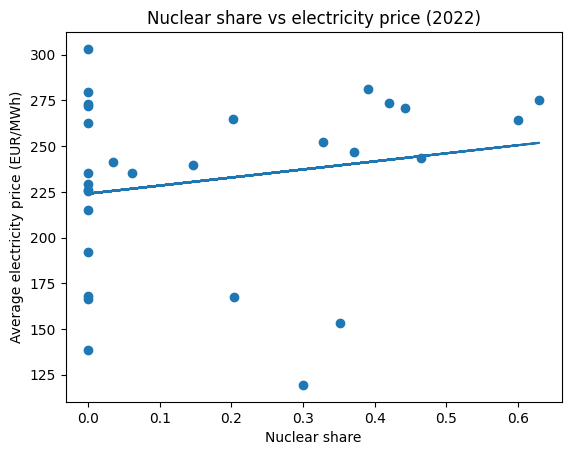

In [15]:
plt.figure()
x = df_y["nuclear_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Nuclear share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Nuclear share vs electricity price ({year})")
plt.show()

In [16]:
df_y["nuclear_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(0.19260189562382396)

Il grafico evidenzia che diverse nazioni del dataset non producono energia elettrica dal nucleare (valori sulla retta nuclear_share=0).

Per questo motivo risulta più efficace dividere l'analisi sui prezzi medi di energia elettrica e distinguerli tra le nazioni che producono e non producono energia elettrica dal nucleare.

In [17]:
with_nuclear = df_y[df_y["nuclear_share"] > 0]
without_nuclear = df_y[df_y["nuclear_share"] == 0]

In [18]:
(
    with_nuclear["AvgPrice_EUR_MWh"].mean(),
    without_nuclear["AvgPrice_EUR_MWh"].mean()
)

(np.float64(235.2482777777778), np.float64(227.51488095238088))

<Figure size 640x480 with 0 Axes>

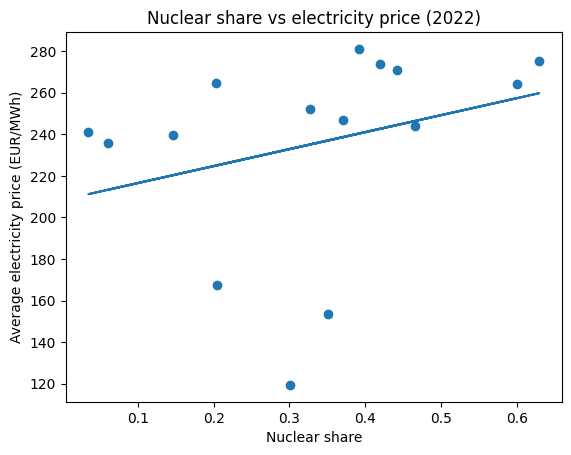

In [19]:
plt.figure()
x = with_nuclear["nuclear_share"]
y = with_nuclear["AvgPrice_EUR_MWh"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Nuclear share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Nuclear share vs electricity price ({year})")
plt.show()

In [20]:
with_nuclear["nuclear_share"].corr(with_nuclear["AvgPrice_EUR_MWh"])

np.float64(0.29446098933138015)

Dal grafico si evince che esiste una correlazione debolmente positiva tra la quota di produzione nucleare e il prezzo della corrente. <br>
In quel periodo i paesi che producono energia dal nucleare tendono ad avere prezzi dell'energia più alti

<Figure size 640x480 with 0 Axes>

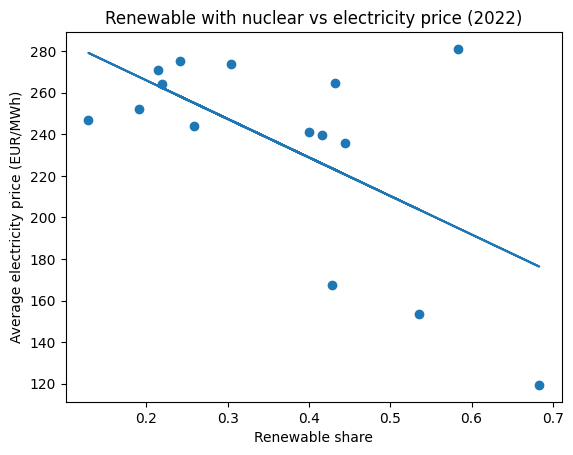

In [21]:
plt.figure()
x = with_nuclear["renewables_share"]
y = with_nuclear["AvgPrice_EUR_MWh"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Renewable share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Renewable with nuclear vs electricity price ({year})")
plt.show()

In [22]:
with_nuclear["renewables_share"].corr(with_nuclear["AvgPrice_EUR_MWh"])

np.float64(-0.6059054414344665)

La correlazione elevata osservata è fortemente influenzata da pochi outlier, come evidenziato dallo scatterplot. Questo suggerisce che il prezzo è probabilmente determinato da fattori esterni al mix produttivo nazionale, come le importazioni.
Per questo motivo viene tentata la correlazione di Spearman

In [23]:
with_nuclear["renewables_share"].corr(with_nuclear["AvgPrice_EUR_MWh"], method="spearman")

np.float64(-0.39999999999999997)

## Limite dell’analisi
Lo share di una fonte sul totale della produzione nazionale non garantisce che tale fonte determini il prezzo dell’elettricità. <br>
In presenza di import significativi, il prezzo può essere guidato da energia acquistata dall’estero, rendendo debole o fuorviante la correlazione tra mix produttivo interno e prezzo medio. <br>
Possiamo trovare conferma osservando la volatilità dei prezzi energetici.

In [24]:
df_y["Has_Nuclear"] = df_y["nuclear_share"] > 0

In [25]:
df_y["is_importer"] = df_y["Net Imports"] > 0
df_y["import_share"] = (
    df_y["Net Imports"].abs() / df_y["Demand"]
)

In [26]:
df_y[["nuclear_share", "renewables_share", "AvgPrice_EUR_MWh"]].corr()

,nuclear_share,renewables_share,AvgPrice_EUR_MWh
nuclear_share,1.000000,-0.511903,0.192602
renewables_share,-0.511903,1.000000,-0.361291
AvgPrice_EUR_MWh,0.192602,-0.361291,1.000000


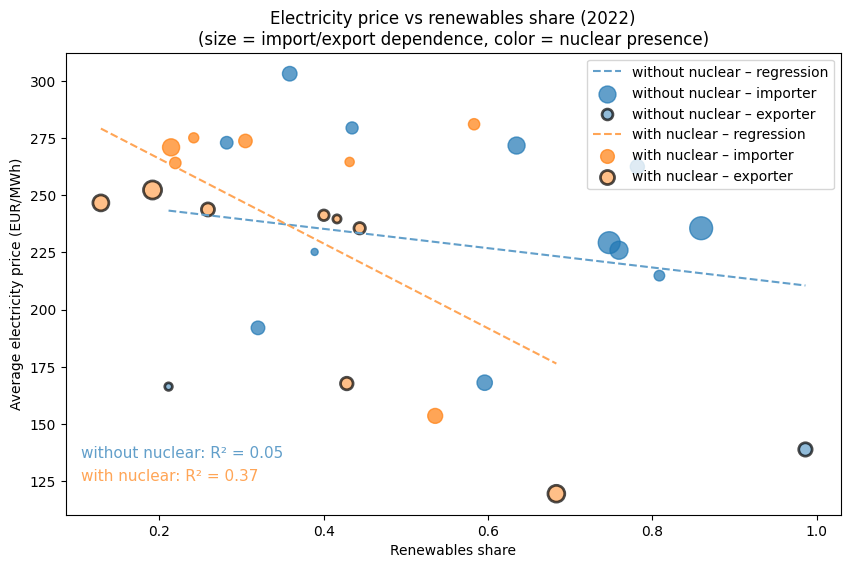

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, g in df_y.groupby("Has_Nuclear"):
    label_str = "with nuclear" if label else "without nuclear"
    color = "#ffa556" if label else "#629fca"

    # calcolo linee di regressione
    X = g["renewables_share"].values.reshape(-1, 1)
    y = g["AvgPrice_EUR_MWh"].values

    # utilizzo sklearn per poter sfruttare la funzione r2_score
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    ax.plot(
        x_line,
        y_line,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=f"{label_str} – regression",
    )

    ax.text(
        0.02,
        0.1 if label else 0.15,
        f"{label_str}: R² = {r2:.2f}",
        transform=ax.transAxes,
        color=color,
        fontsize=11,
        verticalalignment="top"
    )

    
    sizes = 300 * np.sqrt(g["import_share"])

    # Importer
    imp = g[g["is_importer"]]
    ax.scatter(
        imp["renewables_share"],
        imp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(imp["import_share"]),
        alpha=0.7,
        label=f"{label_str} – importer",
    )

    # Exporter
    exp = g[~g["is_importer"]]
    ax.scatter(
        exp["renewables_share"],
        exp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(exp["import_share"]),
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        facecolors="#ffa556" if label else "#629fca",
        label=f"{label_str} – exporter",
    )

ax.set_xlabel("Renewables share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    f"Electricity price vs renewables share ({year})\n"
    "(size = import/export dependence, color = nuclear presence)"
)

ax.legend()
plt.show()


Il grafico mostra che una quota elevata di energia rinnovabile non implica necessariamente prezzi medi dell’elettricità più bassi. I paesi con una forte dipendenza dalle importazioni (rappresentati da marker di dimensione maggiore) tendono a registrare prezzi elevati anche in presenza di un mix produttivo interno prevalentemente rinnovabile. Questo suggerisce che il prezzo dell’elettricità non dipende esclusivamente dalla struttura della produzione nazionale, ma è fortemente influenzato dall’integrazione con il mercato estero.<br>

Le rette di regressione, stimate separatamente per paesi con e senza nucleare, mostrano una relazione lineare debole tra quota di rinnovabili e prezzo medio annuo. Nei paesi privi di nucleare, il valore di R<sup>2</sup> risulta molto basso (≈ 0.05), indicando che la quota di rinnovabili spiega una parte trascurabile della variabilità dei prezzi. Nei paesi dotati di nucleare, R<sup>2</sup> assume valori più elevati (≈ 0.37), ma tale risultato va interpretato con cautela, in quanto la stima risulta sensibile a pochi punti estremi e a una minore variabilità complessiva del sistema.<br><br>

Nel complesso, l’analisi suggerisce che la relazione tra quota rinnovabile e prezzo dell’elettricità risulta debole se considerata isolatamente. La presenza del nucleare non comporta sistematicamente prezzi più bassi, ma sembra essere associata a una maggiore stabilità del sistema, riducendo la dispersione dei prezzi piuttosto che il loro livello medio.

In [28]:
with open('../data/pickles/dataframe_q1.pickle', 'wb') as handle:
    pickle.dump({year: df_y}, handle)

# Q2: Il nucleare è associato a una minore variabilità del prezzo dell’elettricità?

Dal confronto precedente emerge che i prezzi medi dell’elettricità nei paesi con e senza nucleare risultano simili, e che la relazione tra mix produttivo e prezzo è debole. Tuttavia, il valore medio da solo non è sufficiente a descrivere il comportamento del prezzo. <br>

Per questo motivo, l’analisi viene ora estesa alla distribuzione dei prezzi, distinguendo tra paesi con e senza produzione nucleare. In particolare, l’obiettivo è valutare se la presenza del nucleare sia associata a una minore variabilità dei prezzi o a una diversa dispersione. <br>

A tal fine, vengono utilizzati boxplot, che consentono di confrontare in modo diretto mediana, intervalli interquartili e outlier tra i due gruppi di paesi.

In [29]:
year = 2022
df_y = df[df["Year"] == year].copy()

In [30]:
df_y["nuclear_share"] = df_y["Nuclear"] / df_y["Total Generation"]
df_y["Has_Nuclear"] = df_y["nuclear_share"] > 0

with_nuclear = df_y[df_y["Has_Nuclear"]]
without_nuclear = df_y[~df_y["Has_Nuclear"]]

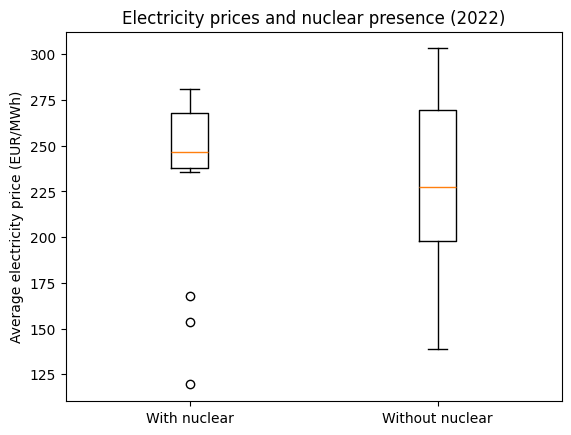

In [31]:
plt.figure()

plt.boxplot(
    [
        with_nuclear["AvgPrice_EUR_MWh"],
        without_nuclear["AvgPrice_EUR_MWh"]
    ],
    tick_labels=["With nuclear", "Without nuclear"]
)

plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Electricity prices and nuclear presence ({year})")
plt.show()


In [32]:
df_y.groupby("Has_Nuclear")["AvgPrice_EUR_MWh"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    q25=lambda x: x.quantile(0.25),
    median="median",
    q75=lambda x: x.quantile(0.75),
    max="max",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

,count,mean,std,min,q25,median,q75,max,IQR
Has_Nuclear,,,,,,,,,
False,14,227.514881,48.275012,138.802500,197.677708,227.570,269.373125,303.088333,71.695417
True,15,235.248278,48.789655,119.453333,237.563750,246.605,267.710833,280.995833,30.147083


Il confronto tra i prezzi medi dell’elettricità nei paesi con e senza produzione nucleare mostra distribuzioni con mediane simili, ma con una differente dispersione. <br>
Nei paesi con nucleare i prezzi risultano concentrati in un intervallo più ristretto, suggerendo un effetto di stabilizzazione piuttosto che di riduzione del prezzo medio.
Al contrario, nei paesi senza nucleare si osserva una maggiore variabilità, con casi di prezzi significativamente più bassi ma anche più elevati.
Troviamo conferma anche tramite il boxplot riferito alle deviazioni standard dei prezzi.

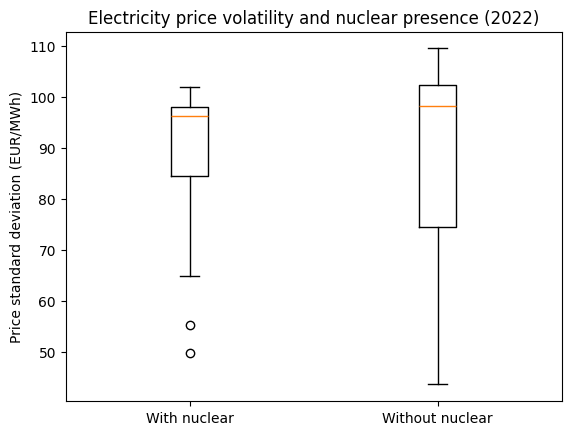

In [33]:
plt.figure()

plt.boxplot(
    [
        with_nuclear["StdPrice_EUR_MWh"],
        without_nuclear["StdPrice_EUR_MWh"]
    ],
    tick_labels=["With nuclear", "Without nuclear"]
)

plt.ylabel("Price standard deviation (EUR/MWh)")
plt.title(f"Electricity price volatility and nuclear presence ({year})")
plt.show()


In [34]:
df_y.groupby("Has_Nuclear")["StdPrice_EUR_MWh"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    q25=lambda x: x.quantile(0.25),
    median="median",
    q75=lambda x: x.quantile(0.75),
    max="max",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

,count,mean,std,min,q25,median,q75,max,IQR
Has_Nuclear,,,,,,,,,
False,14,86.195100,22.510715,43.656337,74.499181,98.186396,102.334896,109.448892,27.835715
True,15,86.924746,16.866465,49.916257,84.506277,96.249709,98.008211,101.984775,13.501934


L’analisi della deviazione standard dei prezzi mostra mediane simili tra paesi con e senza produzione nucleare, indicando che la presenza del nucleare non riduce direttamente la variabilità media del prezzo.
Tuttavia, l’intervallo interquartile risulta significativamente più ristretto nei paesi con nucleare, indicando una maggiore prevedibilità del comportamento dei prezzi.
Il nucleare appare quindi influire più sull’incertezza della volatilità che sul livello medio dei prezzi della corrente.

In [35]:
with open('../data/pickles/dataframe_q2.pickle', 'wb') as handle:
    pickle.dump({year: df_y}, handle)

# Q3: Relazione tra energia fossile e prezzo dell’elettricità

In [36]:
year = 2022
df_y = df[df["Year"] == year].copy()

In [37]:
df_y["fossil_share"] = df_y["Fossil"] / df_y["Total Generation"]

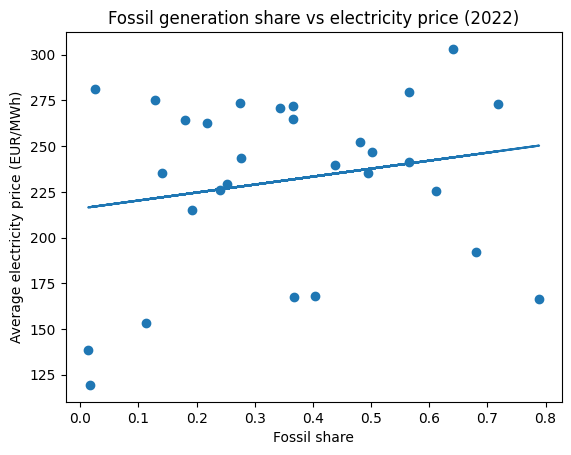

In [38]:
x = df_y["fossil_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Fossil share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Fossil generation share vs electricity price ({year})")
plt.show()

In [39]:
df_y["fossil_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(0.19880154520090557)

In [40]:
df_y["gas_share"] = df_y["Gas"] / df_y["Total Generation"]
df_y["coal_share"] = df_y["Coal"] / df_y["Total Generation"]
df_y["Has_coal"] = df_y["coal_share"] > 0

In [41]:
df_y["is_importer"] = df_y["Net Imports"] > 0
df_y["import_share"] = (
    df_y["Net Imports"].abs() / df_y["Demand"]
)

In [42]:
df_y[["gas_share", "coal_share", "AvgPrice_EUR_MWh"]].corr()


,gas_share,coal_share,AvgPrice_EUR_MWh
gas_share,1.000000,-0.257135,0.250964
coal_share,-0.257135,1.000000,0.113546
AvgPrice_EUR_MWh,0.250964,0.113546,1.000000


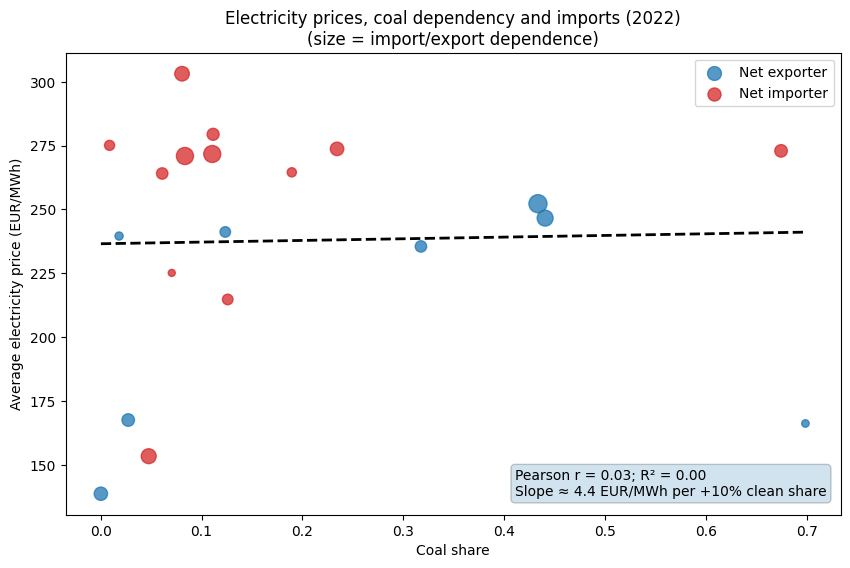

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {True: "#d62728", False: "#1f77b4"}
labels = {True: "Net importer", False: "Net exporter"}

with_coal = df_y[df_y["Has_coal"]]

for is_imp, g in with_coal.groupby("is_importer"):
    ax.scatter(
        g["coal_share"],
        g["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(g["import_share"]),
        alpha=0.75,
        color=colors[is_imp],
        label=labels[is_imp],
    )


X = with_coal["coal_share"].values.reshape(-1, 1)
y = with_coal["AvgPrice_EUR_MWh"].values

model = LinearRegression()
model.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=2)

r2 = r2_score(y, model.predict(X))

corr = with_coal["coal_share"].corr(with_coal["AvgPrice_EUR_MWh"])
plt.annotate(
    f"Pearson r = {corr:.2f}; R² = {r2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% clean share",
    xy=(0.58, 0.1),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

ax.set_xlabel("Coal share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity prices, coal dependency and imports (2022)\n"
    "(size = import/export dependence)"
)

ax.legend()
plt.show()

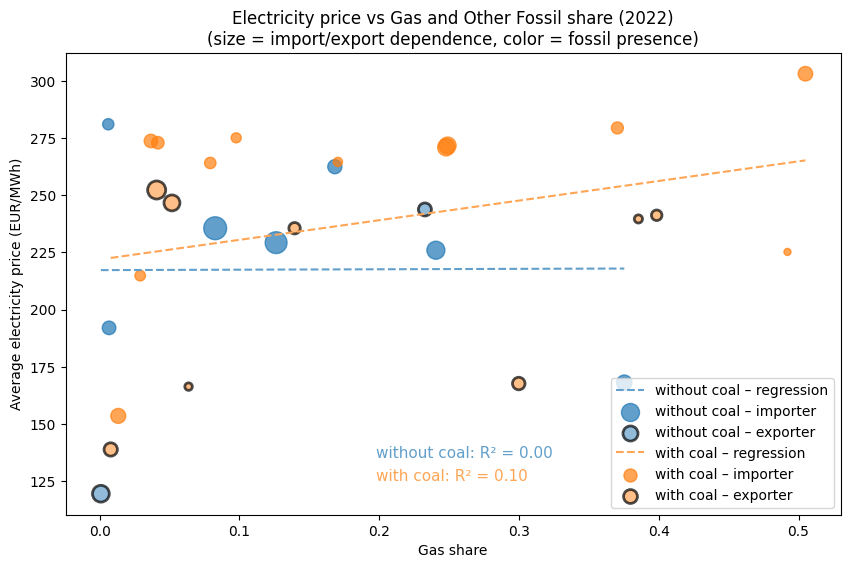

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, g in df_y.groupby("Has_coal"):
    label_str = "with coal" if label else "without coal"
    color = "#ffa556" if label else "#629fca"

    # calcolo linee di regressione
    X = g["gas_share"].values.reshape(-1, 1)
    y = g["AvgPrice_EUR_MWh"].values

    # utilizzo sklearn per poter sfruttare la funzione r2_score
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    ax.plot(
        x_line,
        y_line,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=f"{label_str} – regression",
    )

    ax.text(
        0.40,
        0.1 if label else 0.15,
        f"{label_str}: R² = {r2:.2f}",
        transform=ax.transAxes,
        color=color,
        fontsize=11,
        verticalalignment="top"
    )

    
    sizes = 300 * np.sqrt(g["import_share"])

    # Importer
    imp = g[g["is_importer"]]
    ax.scatter(
        imp["gas_share"],
        imp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(imp["import_share"]),
        alpha=0.7,
        label=f"{label_str} – importer",
    )

    # Exporter
    exp = g[~g["is_importer"]]
    ax.scatter(
        exp["gas_share"],
        exp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(exp["import_share"]),
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        facecolors="#ffa556" if label else "#629fca",
        label=f"{label_str} – exporter",
    )

ax.set_xlabel("Gas share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    f"Electricity price vs Gas and Other Fossil share ({year})\n"
    "(size = import/export dependence, color = fossil presence)"
)

ax.legend()
plt.show()


Lo scatter mostra l’assenza di una relazione lineare significativa tra quota di gas e prezzo medio dell’elettricità, ma mostra invece una dipendenza dalle importazioni: i paesi importatori mostrano prezzi più elevati, indipendentemente dalla quota di gas nella produzione interna.

In [45]:
with open('../data/pickles/dataframe_q3.pickle', 'wb') as handle:
    pickle.dump({year: df_y}, handle)

# Q4: Influenza delle importazioni sul prezzo dell’elettricità
Un’elevata produzione nazionale da fonti pulite o fossili non garantisce prezzi bassi se il fabbisogno interno supera la produzione e il paese dipende dalle importazioni.

In [46]:
year = 2022
df_y = df[df["Year"] == year].copy()

In [47]:
df_y["Renewables"] = (
    df_y["Wind and Solar"] +
    df_y["Hydro, Bioenergy and Other Renewables"]
)

In [48]:
df_y["total_generation_share"] = df_y["Total Generation"] / df_y["Demand"]
df_y["import_share"] = df_y["Net Imports"] / df_y["Demand"]

df_y["clean_share"] = df_y["Clean"] / df_y["Total Generation"]
df_y["nuclear_share"] = df_y["Nuclear"] / df_y["Total Generation"]
df_y["renewables_share"] = df_y["Renewables"] / df_y["Total Generation"]
df_y["fossil_share"] = df_y["Fossil"] / df_y["Total Generation"]
df_y["coal_share"] = df_y["Coal"] / df_y["Total Generation"]
df_y["gas_share"] = df_y["Gas and Other Fossil"] / df_y["Total Generation"]

In [49]:
df_y["import_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(0.1670346149743313)

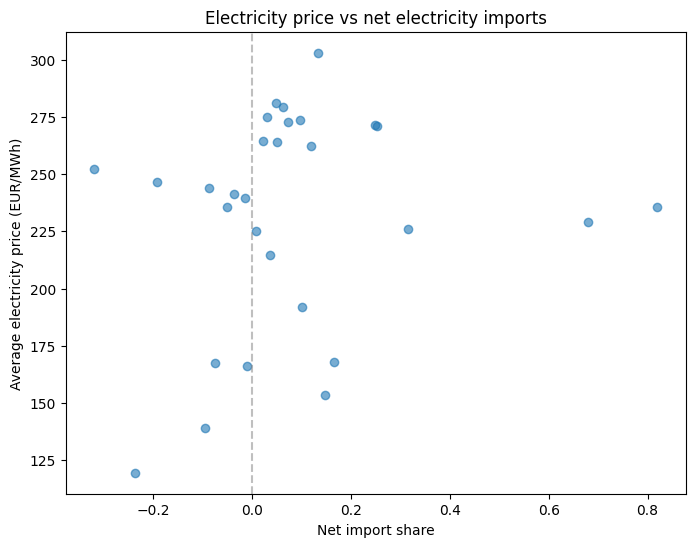

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_y["import_share"],
    df_y["AvgPrice_EUR_MWh"],
    alpha=0.6
)
plt.axvline(0, linestyle="--", color="gray", alpha=0.5)
plt.xlabel("Net import share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title("Electricity price vs net electricity imports")
plt.show()

In [51]:
df_y[[
    "AvgPrice_EUR_MWh",
    "clean_share",
    "nuclear_share",
    "renewables_share",
    "fossil_share",
    "coal_share",
    "gas_share",
    "total_generation_share",
    "import_share"
]].corr()

,AvgPrice_EUR_MWh,clean_share,nuclear_share,renewables_share,fossil_share,coal_share,gas_share,total_generation_share,import_share
AvgPrice_EUR_MWh,1.000000,-0.198802,0.192602,-0.361291,0.198802,0.113546,0.113591,-0.167035,0.167035
clean_share,-0.198802,1.000000,0.413476,0.570512,-1.000000,-0.604948,-0.535536,-0.166564,0.166564
nuclear_share,0.192602,0.413476,1.000000,-0.511903,-0.413476,-0.076625,-0.405450,0.310947,-0.310947
renewables_share,-0.361291,0.570512,-0.511903,1.000000,-0.570512,-0.501633,-0.139544,-0.437624,0.437624
fossil_share,0.198802,-1.000000,-0.413476,-0.570512,1.000000,0.604948,0.535536,0.166564,-0.166564
coal_share,0.113546,-0.604948,-0.076625,-0.501633,0.604948,1.000000,-0.348485,0.312171,-0.312171
gas_share,0.113591,-0.535536,-0.405450,-0.139544,0.535536,-0.348485,1.000000,-0.135018,0.135018
total_generation_share,-0.167035,-0.166564,0.310947,-0.437624,0.166564,0.312171,-0.135018,1.000000,-1.000000
import_share,0.167035,0.166564,-0.310947,0.437624,-0.166564,-0.312171,0.135018,-1.000000,1.000000


In [52]:
df_y["Has_Nuclear"] = df_y["nuclear_share"] > 0
df_y["Has_Gas"] = df_y["coal_share"] > 0.05  # soglia minima `significativa`

In [53]:
df_y["Energy_Category"] = (
    df_y["Has_Nuclear"].map({True: "Nuclear", False: "No Nuclear"})
    + " / "
    + df_y["Has_Gas"].map({True: "Gas", False: "No Gas"})
)

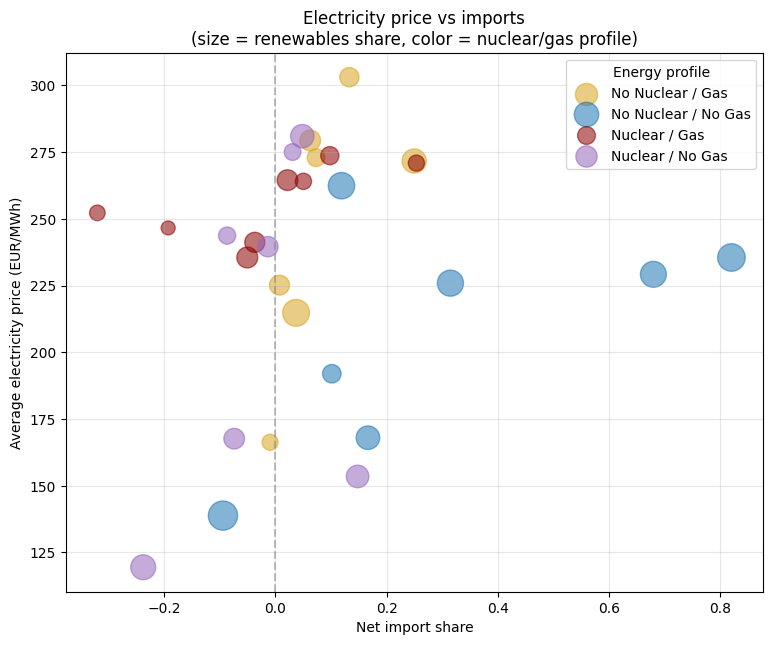

In [54]:
fig, ax = plt.subplots(figsize=(9, 7))

color_map = {
"No Nuclear / No Gas": "tab:blue",
"No Nuclear / Gas": "goldenrod",
"Nuclear / No Gas": "tab:purple",
"Nuclear / Gas": "darkred"
}

for label, g in df_y.groupby("Energy_Category"):
    ax.scatter(
        g["import_share"],
        g["AvgPrice_EUR_MWh"],
        color=color_map[label],
        s=400 * g["renewables_share"] + 50,
        alpha=0.55,
        label=label
    )

ax.axvline(0, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Net import share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity price vs imports\n"
    "(size = renewables share, color = nuclear/gas profile)"
)
ax.legend(title="Energy profile")
plt.grid(alpha=0.3)
plt.show()

Segmentando i paesi in base alla presenza di nucleare e carbone emerge che i paesi dotati di produzione di corrente elettrica costante (nucleare e/o carbone) tendono ad avere una minore dipendenza dalle importazioni. Al contrario, i paesi con un’elevata quota di rinnovabili e assenza di fonti programmate mostrano una maggiore dipendenza al mercato estero, con effetti rilevanti sul prezzo finale dell’elettricità.

Un’eccezione rilevante è rappresentata dalla Norvegia, caratterizzata da una produzione quasi interamente idroelettrica. A differenza delle altre fonti rinnovabili, l’idroelettrico fornisce capacità programmabile e di stoccaggio, consentendo al paese di essere esportatore netto e di mantenere prezzi medi relativamente bassi.

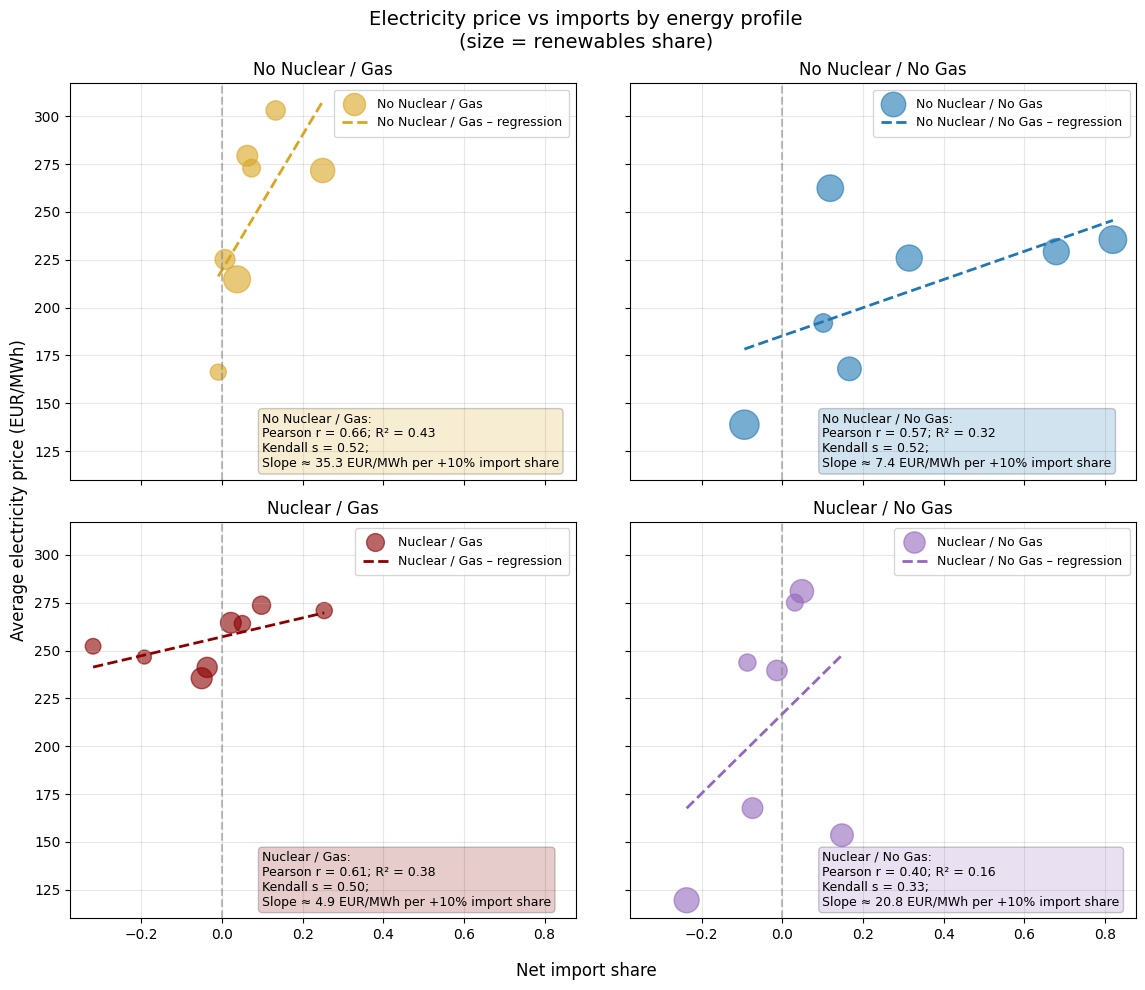

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

color_map = {
    "No Nuclear / No Gas": "tab:blue",
    "No Nuclear / Gas": "goldenrod",
    "Nuclear / No Gas": "tab:purple",
    "Nuclear / Gas": "darkred"
}

for ax, (label, g) in zip(axes, df_y.groupby("Energy_Category")):
    handles = []
    legend_labels = []
    group_name = label
    x = g["import_share"]
    y = g["AvgPrice_EUR_MWh"]
    sc = ax.scatter(
        x,
        y,
        color=color_map[group_name],
        s=400 * g["renewables_share"] + 50,
        alpha=0.6
    )

    handles.append(sc)
    legend_labels.append(f"{group_name}")


    corr_p = g["import_share"].corr(g["AvgPrice_EUR_MWh"])
    corr_t = g["import_share"].corr(g["AvgPrice_EUR_MWh"], method="kendall")

    if abs(corr_p) >= 0.05:
        m, q = np.polyfit(x, y, 1)
        
        regression_x = [min(x), max(x)]
        regression_y = [m*_x + q for _x in regression_x]
        reg_line, = ax.plot(
            regression_x,
            regression_y,
            linestyle="--",
            linewidth=2,
            color=color_map[group_name]
        )
        handles.append(reg_line)
        legend_labels.append(f"{group_name} – regression")

        # annotazioni
        ax.annotate(
            f"{group_name}:\n"
            f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nKendall s = {corr_t:.2f};\n"
            f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% import share",
            xy=(0.38, 0.17),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.2, facecolor=color_map[group_name])
        )

    ax.legend(handles=handles, labels=legend_labels, fontsize=9, borderpad=0.6, labelspacing=0.5)
    
    ax.axvline(0, linestyle="--", color="gray", alpha=0.5)
    ax.set_title(label)
    ax.grid(alpha=0.3)

# etichette comuni
fig.supxlabel("Net import share")
fig.supylabel("Average electricity price (EUR/MWh)")

fig.suptitle(
    "Electricity price vs imports by energy profile\n"
    "(size = renewables share)",
    fontsize=14
)

plt.tight_layout()
plt.show()

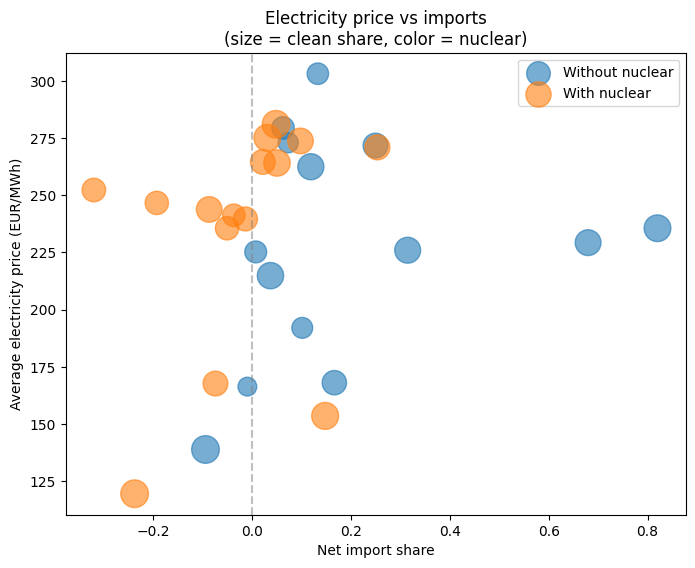

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, g in df_y.groupby("Has_Nuclear"):
    ax.scatter(
        g["import_share"],
        g["AvgPrice_EUR_MWh"],
        s=400 * np.sqrt(g["clean_share"]),
        alpha=0.6,
        label="With nuclear" if label else "Without nuclear"
    )

ax.axvline(0, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Net import share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title("Electricity price vs imports\n(size = clean share, color = nuclear)")
ax.legend()
plt.show()

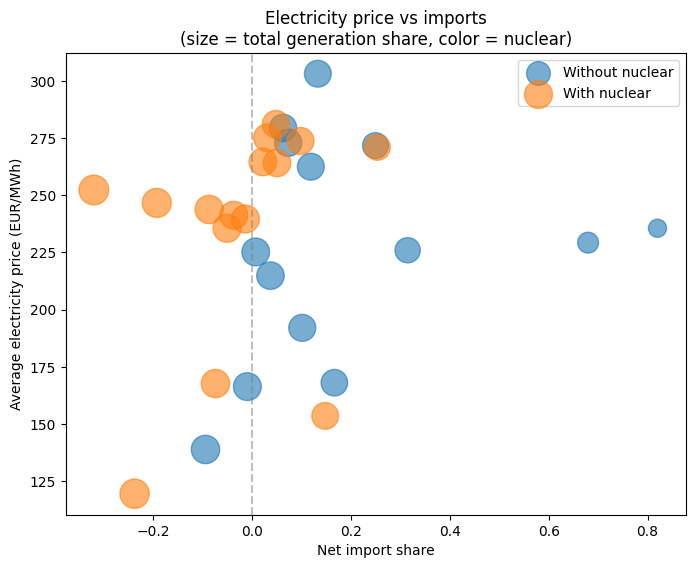

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, g in df_y.groupby("Has_Nuclear"):
    ax.scatter(
        g["import_share"],
        g["AvgPrice_EUR_MWh"],
        s=400 * np.sqrt(g["total_generation_share"]),
        alpha=0.6,
        label="With nuclear" if label else "Without nuclear"
    )

ax.axvline(0, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Net import share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title("Electricity price vs imports\n(size = total generation share, color = nuclear)")
ax.legend()
plt.show()

In [58]:
df_y["Is_Importer"] = df_y["import_share"] > 0

df_y.groupby("Is_Importer")["AvgPrice_EUR_MWh"].describe()

,count,mean,std,min,25%,50%,75%,max
Is_Importer,,,,,,,,
False,10.0,205.109250,51.098987,119.453333,166.618958,237.563750,243.106042,252.249167
True,19.0,245.412632,40.765566,153.479167,225.542083,264.066667,273.305000,303.088333


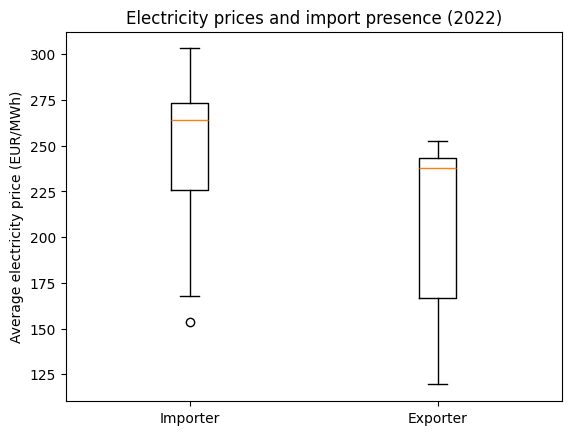

In [59]:
plt.figure()

plt.boxplot(
    [
        df_y[df_y["Is_Importer"]]["AvgPrice_EUR_MWh"],
        df_y[~df_y["Is_Importer"]]["AvgPrice_EUR_MWh"]
    ],
    tick_labels=["Importer", "Exporter"]
)

plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Electricity prices and import presence ({year})")
plt.show()


In [60]:
df_y.groupby("Is_Importer")["AvgPrice_EUR_MWh"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    q25=lambda x: x.quantile(0.25),
    median="median",
    q75=lambda x: x.quantile(0.75),
    max="max",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

,count,mean,std,min,q25,median,q75,max,IQR
Is_Importer,,,,,,,,,
False,10,205.109250,51.098987,119.453333,166.618958,237.563750,243.106042,252.249167,76.487083
True,19,245.412632,40.765566,153.479167,225.542083,264.066667,273.305000,303.088333,47.762917


Il boxplot evidenzia che i paesi importatori presentano prezzi medi dell’elettricità più elevati ma con una dispersione inferiore rispetto agli esportatori. Al contrario, i paesi esportatori mostrano una maggiore variabilità dei prezzi, suggerendo modelli energetici più eterogenei e una minore dipendenza da un prezzo comune.

In [61]:
with open('../data/pickles/dataframe_q4.pickle', 'wb') as handle:
    pickle.dump({year: df_y}, handle)

# Q5: Quali caratteristiche strutturali del mix energetico presentano i paesi con i prezzi più elevati dell’elettricità?
L'obiettivo è capire se esistono dei tratti comuni tra i principali paesi che possiedono prezzi energetici più elevati

In [62]:
year = 2022
df_y = df[df["Year"] == year].copy()

In [63]:
df_y.columns

Index(['Area', 'ISO3 Code', 'Year', 'Demand', 'Net Imports',
       'Total Generation', 'Clean', 'Nuclear', 'Wind and Solar', 'Wind',
       'Solar', 'Hydro, Bioenergy and Other Renewables', 'Hydro', 'Bioenergy',
       'Other Renewables', 'Fossil', 'Coal', 'Gas and Other Fossil', 'Gas',
       'Other Fossil', 'AvgPrice_EUR_MWh', 'MaxPrice_EUR_MWh',
       'StdPrice_EUR_MWh'],
      dtype='object')

In [64]:
df_y["Renewables"] = (
    df_y["Wind and Solar"] +
    df_y["Hydro, Bioenergy and Other Renewables"]
)

In [65]:
df_y["demand_ratio"] = df_y["Demand"] / df_y["Demand"].max()
df_y["import_share"] = df_y["Net Imports"] / df_y["Demand"]
df_y["total_generation_share"] = df_y["Total Generation"] / df_y["Demand"]

df_y["clean_share"] = df_y["Clean"] / df_y["Total Generation"]
df_y["nuclear_share"] = df_y["Nuclear"] / df_y["Total Generation"]
df_y["renewables_share"] = df_y["Renewables"] / df_y["Total Generation"]
df_y["fossil_share"] = df_y["Fossil"] / df_y["Total Generation"]
df_y["coal_share"] = df_y["Coal"] / df_y["Total Generation"]
df_y["gas_share"] = df_y["Gas and Other Fossil"] / df_y["Total Generation"]

In [66]:
top_countries = (
    df_y
    .sort_values("AvgPrice_EUR_MWh", ascending=False)
    .head(6)["Area"]
)
top_countries

131          Italy
270    Switzerland
104         Greece
84          France
240       Slovenia
220         Serbia
Name: Area, dtype: object

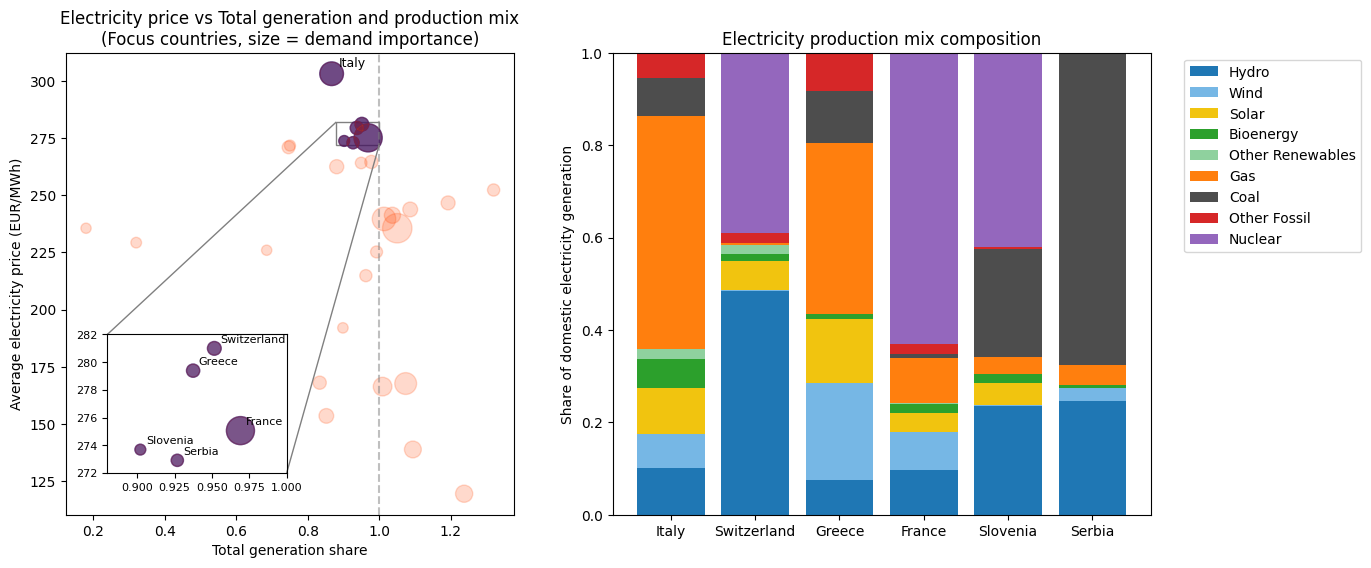

In [67]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


df_focus = df_y[df_y["Area"].isin(top_countries)].sort_values("AvgPrice_EUR_MWh", ascending=False).set_index("Area")


fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.2]})


# ======================
# PANNELLO 1 — SCATTER
# ======================
ax = axes[0]


# ---- INSET ZOOM ----

axins = inset_axes(
    ax,
    width="40%",
    height="30%",
    loc="lower left",
    borderpad=3
)

axins.scatter(
    df_focus["total_generation_share"],
    df_focus["AvgPrice_EUR_MWh"],
    color = "navy",
    s=400 * df_focus["demand_ratio"] + 50,
    alpha=0.65
)


axins.scatter(
    df_y["total_generation_share"],
    df_y["AvgPrice_EUR_MWh"],
    color = "orangered",
    s=400 * df_y["demand_ratio"] + 50,
    alpha=0.2
)

# limiti dello zoom per grafico inset
axins.set_xlim(0.88, 1.0)
axins.set_ylim(272, 282)

country_alreay_labels = []

for country, row in df_focus.iterrows():
    if 0.88 <= row["total_generation_share"] <= 1.0 and 272 <= row["AvgPrice_EUR_MWh"] <= 282:
        axins.annotate(
            country,
            (row["total_generation_share"], row["AvgPrice_EUR_MWh"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )
        country_alreay_labels.append(country)

axins.tick_params(labelsize=8)

# rettangolo + linee di collegamento
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray")

# ---- scatter points ---- #

ax.scatter(
    df_focus["total_generation_share"],
    df_focus["AvgPrice_EUR_MWh"],
    color = "navy",
    s= 400 * df_focus["demand_ratio"] + 50,
    alpha = 0.7
)

ax.scatter(
    df_y["total_generation_share"],
    df_y["AvgPrice_EUR_MWh"],
    color = "orangered",
    s= 400 * df_y["demand_ratio"] + 50,
    alpha = 0.2
)



for country, row in df_focus.iterrows():
    if country not in country_alreay_labels:
        ax.annotate(
            country,
            (row["total_generation_share"], row["AvgPrice_EUR_MWh"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )


ax.axvline(1, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Total generation share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title("Electricity price vs Total generation and production mix\n"
            "(Focus countries, size = demand importance)")


# ============================
# PANNELLO 2 — STACKED BAR
# ============================
ax2 = axes[1]


energy_components = {
    "Hydro": df_focus["Hydro"],
    "Wind": df_focus["Wind"],
    "Solar": df_focus["Solar"],
    "Bioenergy": df_focus["Bioenergy"],
    "Other Renewables": df_focus["Other Renewables"],
    "Gas": df_focus["Gas"],
    "Coal": df_focus["Coal"],
    "Other Fossil": df_focus["Other Fossil"],
    "Nuclear": df_focus["Nuclear"],
}

energy_colors = {
    "Hydro": "#1f77b4",            # blu
    "Wind": "#76b7e5",             # azzurro
    "Solar": "#f1c40f",            # giallo
    "Bioenergy": "#2ca02c",        # verde
    "Other Renewables": "#8fd19e", # verde chiaro

    "Gas": "#ff7f0e",              # arancione
    "Coal": "#4d4d4d",             # quasi nero
    "Other Fossil": "#d62728",     # rosso scuro

    "Nuclear": "#9467bd",          # viola
}

bottom = np.zeros(len(df_focus))

for label, values in energy_components.items():
    share = values / df_focus["Total Generation"]
    ax2.bar(
        df_focus.index,
        share,
        bottom=bottom,
        label=label,
        color=energy_colors[label]
    )
    bottom += share

ax2.set_ylabel("Share of domestic electricity generation")
ax2.set_title("Electricity production mix composition")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


#plt.tight_layout()
plt.show()

Paesi con un’elevata quota di rinnovabili possono presentare prezzi dell’elettricità molto diversi a seconda:
- della scala della domanda elettrica
- della struttura della produzione
- della dipendenza dalle importazioni

L'Italia e la Francia presentano prezzi elevati quasi sicuramente per il costo del gas per l'una, mentre i costi nascosti del nucleare per l'altra (come ad esempio costi di manutenzione e altri oneri di sistema).

In [68]:
bottom_countries = (
    df_y
    .sort_values("AvgPrice_EUR_MWh", ascending=True)
    .head(6)["Area"]
)
top_countries

131          Italy
270    Switzerland
104         Greece
84          France
240       Slovenia
220         Serbia
Name: Area, dtype: object

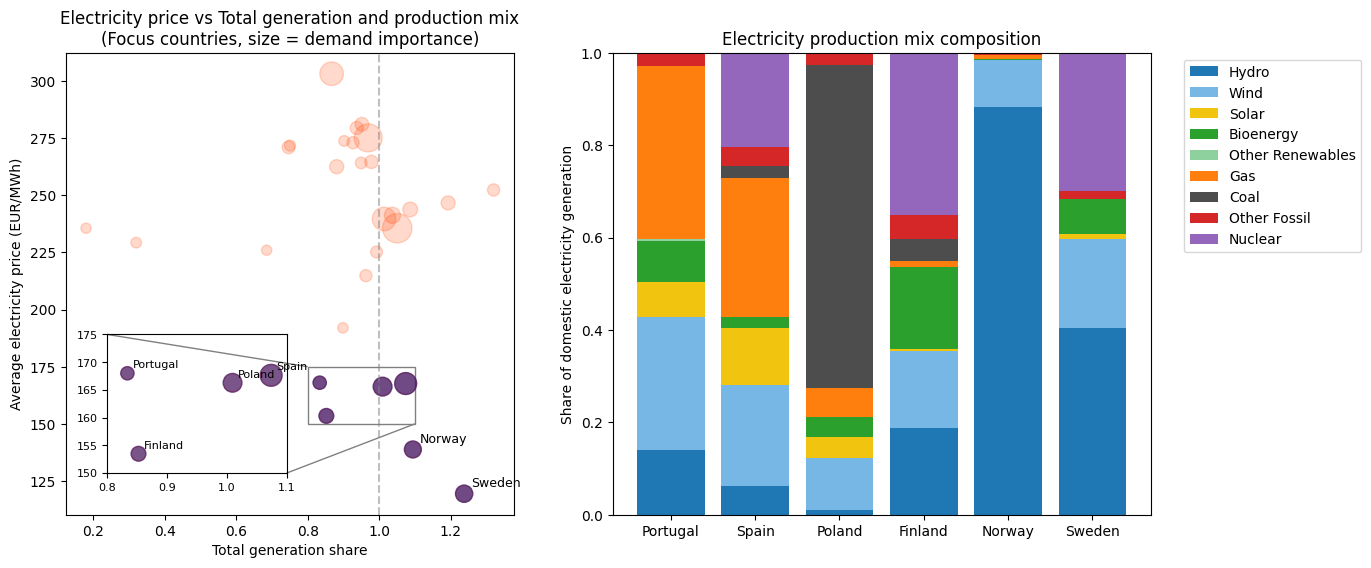

In [69]:

df_focus = df_y[df_y["Area"].isin(bottom_countries)].sort_values("AvgPrice_EUR_MWh", ascending=False).set_index("Area")


fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.2]})


# ======================
# PANNELLO 1 — SCATTER
# ======================
ax = axes[0]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ======================
# INSET ZOOM
# ======================
axins = inset_axes(
    ax,
    width="40%",
    height="30%",
    loc="lower left",
    borderpad=3
)

# stessi scatter del grafico principale

axins.scatter(
    df_focus["total_generation_share"],
    df_focus["AvgPrice_EUR_MWh"],
    color = "navy",
    s=400 * df_focus["demand_ratio"] + 50,
    alpha=0.65
)


axins.scatter(
    df_y["total_generation_share"],
    df_y["AvgPrice_EUR_MWh"],
    color = "orangered",
    s=400 * df_y["demand_ratio"] + 50,
    alpha=0.2
)

# limiti dello zoom
axins.set_xlim(0.8, 1.1)
axins.set_ylim(150, 175)

country_alreay_labels = []

# etichette SOLO qui
for country, row in df_focus.iterrows():
    if 0.8 <= row["total_generation_share"] <= 1.1 and 150 <= row["AvgPrice_EUR_MWh"] <= 175:
        axins.annotate(
            country,
            (row["total_generation_share"], row["AvgPrice_EUR_MWh"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )
        country_alreay_labels.append(country)

axins.tick_params(labelsize=8)

# rettangolo + linee di collegamento
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray")

ax.scatter(
    df_focus["total_generation_share"],
    df_focus["AvgPrice_EUR_MWh"],
    color = "navy",
    s= 400 * df_focus["demand_ratio"] + 50,
    alpha = 0.7
)

ax.scatter(
    df_y["total_generation_share"],
    df_y["AvgPrice_EUR_MWh"],
    color = "orangered",
    s= 400 * df_y["demand_ratio"] + 50,
    alpha = 0.2
)



for country, row in df_focus.iterrows():
    if country not in country_alreay_labels:
        ax.annotate(
            country,
            (row["total_generation_share"], row["AvgPrice_EUR_MWh"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )


ax.axvline(1, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Total generation share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title("Electricity price vs Total generation and production mix\n"
            "(Focus countries, size = demand importance)")


# ============================
# PANNELLO 2 — STACKED BAR
# ============================
ax2 = axes[1]


energy_components = {
    "Hydro": df_focus["Hydro"],
    "Wind": df_focus["Wind"],
    "Solar": df_focus["Solar"],
    "Bioenergy": df_focus["Bioenergy"],
    "Other Renewables": df_focus["Other Renewables"],
    "Gas": df_focus["Gas"],
    "Coal": df_focus["Coal"],
    "Other Fossil": df_focus["Other Fossil"],
    "Nuclear": df_focus["Nuclear"],
}

energy_colors = {
    "Hydro": "#1f77b4",            # blu
    "Wind": "#76b7e5",             # azzurro
    "Solar": "#f1c40f",            # giallo
    "Bioenergy": "#2ca02c",        # verde
    "Other Renewables": "#8fd19e", # verde chiaro

    "Gas": "#ff7f0e",              # arancione
    "Coal": "#4d4d4d",             # quasi nero
    "Other Fossil": "#d62728",     # rosso scuro

    "Nuclear": "#9467bd",          # viola
}

bottom = np.zeros(len(df_focus))

for label, values in energy_components.items():
    share = values / df_focus["Total Generation"]
    ax2.bar(
        df_focus.index,
        share,
        bottom=bottom,
        label=label,
        color=energy_colors[label]
    )
    bottom += share

ax2.set_ylabel("Share of domestic electricity generation")
ax2.set_title("Electricity production mix composition")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


#plt.tight_layout()
plt.show()

In [70]:
with open('../data/pickles/dataframe_q5.pickle', 'wb') as handle:
    pickle.dump({year: df_y}, handle)

# Sintesi

In [71]:
year = 2022
df_y = df[df["Year"] == year].copy()

In [72]:
df_y["Renewables"] = (
    df_y["Wind and Solar"] +
    df_y["Hydro, Bioenergy and Other Renewables"]
)

In [73]:
df_y["is_importer"] = df_y["Net Imports"] > 0
df_y["import_share"] = (
    df_y["Net Imports"].abs() / df_y["Demand"]
)

df_y["nuclear_share"] = df_y["Nuclear"] / df_y["Total Generation"]
df_y["renewables_share"] = df_y["Renewables"] / df_y["Total Generation"]
df_y["fossil_share"] = df_y["Fossil"] / df_y["Total Generation"]
df_y["coal_share"] = df_y["Coal"] / df_y["Total Generation"]
df_y["gas_and_other_fossil_share"] = df_y["Gas and Other Fossil"]/df_y["Total Generation"]

In [74]:
label_angles = {
    "gas_and_other_fossil": 0,
    "coal": np.pi / 2,
    "nuclear": np.pi,
    "renewables": 3 * np.pi / 2
}

x = (
    df_y["gas_and_other_fossil_share"] * np.cos(label_angles["gas_and_other_fossil"]) +
    df_y["coal_share"] * np.cos(label_angles["coal"]) +
    df_y["nuclear_share"] * np.cos(label_angles["nuclear"]) +
    df_y["renewables_share"] * np.cos(label_angles["renewables"])
)

y = (
    df_y["gas_and_other_fossil_share"] * np.sin(label_angles["gas_and_other_fossil"]) +
    df_y["coal_share"] * np.sin(label_angles["coal"]) +
    df_y["nuclear_share"] * np.sin(label_angles["nuclear"]) +
    df_y["renewables_share"] * np.sin(label_angles["renewables"])
)

theta = np.arctan2(y, x)

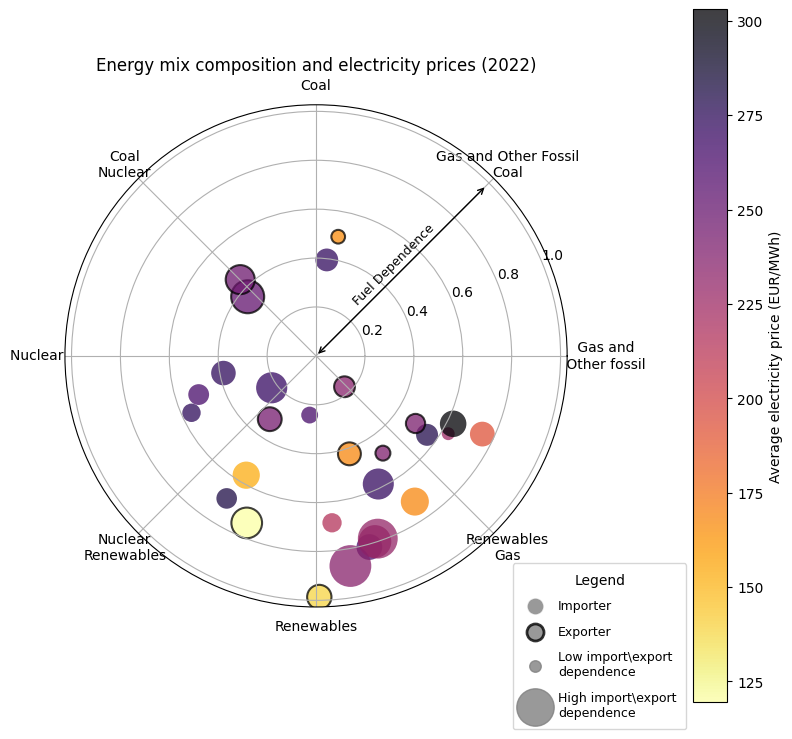

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# ---- labels grafico ---- #
labels = {
    "gas_and_other_fossil": "         Gas and\n         Other fossil",
    "coal": "Coal",
    "nuclear": "Nuclear    ",
    "renewables": "Renewables"
}

mid_labels_angles = {
    "Gas and Other Fossil\nCoal": (label_angles["gas_and_other_fossil"] + label_angles["coal"])/2,
    "Coal\nNuclear": (label_angles["coal"] + label_angles["nuclear"])/2,
    "Nuclear\nRenewables": (label_angles["nuclear"] + label_angles["renewables"])/2,
    "Renewables\nGas": (label_angles["renewables"] + 2 * np.pi)/2,
}

# ---- calcolo posizioni polari ---- #

x_total = np.zeros(len(df_y))
y_total = np.zeros(len(df_y))

for col, theta in label_angles.items():
    x_total += df_y[f"{col}_share"] * np.cos(theta)
    y_total += df_y[f"{col}_share"] * np.sin(theta)

theta_final = np.arctan2(y_total, x_total)
r_final = np.sqrt(x_total**2 + y_total**2)


fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(projection='polar')


# ---- posizionamento punti su grafico ---- #

sc = ax.scatter(
    theta_final,
    r_final,
    c=df_y["AvgPrice_EUR_MWh"],
    cmap="inferno_r", #'YlGnBu',
    s= 1000 * np.sqrt(df_y["import_share"]),
    edgecolors = np.where(df_y["is_importer"], "none", "black"),
    linewidth= np.where(df_y["is_importer"], 0, 1.5),
    alpha=0.75
)

# ---- posizionamento annotazioni ---- #

theta_arrow = np.pi/4
arrow_radius = 1 * r_final.max()


ax.annotate(
    '', 
    xy=(theta_arrow, arrow_radius),      # punta
    xytext=(0, 0),                       # origine
    arrowprops=dict(arrowstyle='<->', color='black', lw=1)
)

ax.text(
    theta_arrow + 0.08, 
    arrow_radius*0.5, 
    "Fuel Dependence", 
    rotation=45,
    ha='center', 
    va='center',                
    fontsize=9
)

# ---- legenda ---- #

# (import/export)
import_patch = plt.scatter([], [], marker='o', color='w', label='Importer', facecolor='gray', s=150, alpha=0.8)
export_patch = plt.scatter([], [], marker='o', color='black', label='Exporter', facecolor='gray', s=150, alpha=0.8, linewidth=2)


# (import share)
small = plt.scatter([], [], s=min(800 * np.sqrt(df_y["import_share"])), color='gray', alpha=0.8, label='Low import\\export\ndependence')
large = plt.scatter([], [], s=max(800 * np.sqrt(df_y["import_share"])), color='gray', alpha=0.8, label='High import\\export\ndependence')


# legend combinata
ax.legend(handles=[import_patch, export_patch, small, large],
loc='upper right', bbox_to_anchor=(1.25, 0.10), title='Legend', borderpad=0.8, labelspacing=1, fontsize=9)




plt.colorbar(sc, ax=ax, label="Average electricity price (EUR/MWh)", fraction=0.1, pad=0.18)
ax.set_title("Energy mix composition and electricity prices (2022)")

ax.set_xticks(list(label_angles.values()) + (list(mid_labels_angles.values())))
ax.set_xticklabels([labels[f] for f in label_angles.keys()] + (list(mid_labels_angles.keys())), fontsize=10)

plt.show()

In [76]:
with open('../data/pickles/dataframe_sintesi.pickle', 'wb') as handle:
    pickle.dump({year: df_y}, handle)